# Predict Tommy Award Winners for Other NBA Teams

This notebook trains the same Random Forest model as `random_forest_classifier.ipynb` (on Celtics games), then uses it to predict the per-game "Tommy Award" winner for another NBA team. Defaults to the **New York Knicks**; change `TARGET_TEAM_NAME` to try any other team.

The pipeline:
1. Trains the Random Forest on Celtics player-game data (Optuna-tuned).
2. Pulls the target team's schedule + box scores (traditional, hustle, advanced) from `nba_api`.
3. Reconstructs the exact engineered features used in training (per-minute stats, hustle proxy, per-game ranks, etc.).
4. Assigns each game's Tommy Award to the player with the highest predicted probability.

In [31]:

from pathlib import Path
import random

import numpy as np
import pandas as pd

SEED = 58
random.seed(SEED)
np.random.seed(SEED)

csv_path = Path("Tommy_Award_Player_Game_Table_hustle.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"Could not find dataset at: {csv_path.resolve()}")

df = pd.read_csv(csv_path)
print(f"Loaded {len(df):,} rows and {len(df.columns)} columns from {csv_path.name}")
df.head()

Loaded 8,530 rows and 60 columns from Tommy_Award_Player_Game_Table_hustle.csv


,gameId,teamId,teamCity,teamName,teamTricode,teamSlug,personId,firstName,familyName,nameI,...,assists_rank,steals_rank,blocks_rank,plusMinusPoints_rank,minutes_decimal_rank,deflections,deflections_missing,charges_drawn,charges_drawn_missing,usage_rate
0,21600006,1610612738,Boston,Celtics,BOS,celtics,203109,Jae,Crowder,J. Crowder,...,7.0,2.0,4.0,4.0,3.0,4.0,0,0.0,0,0.00227
1,21600006,1610612738,Boston,Celtics,BOS,celtics,101161,Amir,Johnson,A. Johnson,...,7.0,5.0,5.0,3.0,6.0,3.0,0,0.0,0,0.00185
2,21600006,1610612738,Boston,Celtics,BOS,celtics,201143,Al,Horford,A. Horford,...,2.0,8.0,1.0,2.0,5.0,1.0,0,0.0,0,0.00145
3,21600006,1610612738,Boston,Celtics,BOS,celtics,202340,Avery,Bradley,A. Bradley,...,2.0,5.0,5.0,4.0,1.0,4.0,0,0.0,0,0.00222
4,21600006,1610612738,Boston,Celtics,BOS,celtics,202738,Isaiah,Thomas,I. Thomas,...,1.0,2.0,5.0,1.0,2.0,2.0,0,0.0,0,0.00253


In [32]:
target_col = "y"
numeric_feature_cols = [
    "minutes_decimal",
    "points",
    "reboundsOffensive",
    "reboundsDefensive",
    "reboundsTotal",
    "assists",
    "steals",
    "blocks",
    "deflections",
    "charges_drawn",
    "turnovers",
    "foulsPersonal",
    "plusMinusPoints",
    "net_rating",
    "usage_rate",
    "impact_efficiency",
    "role_outperformance",
    "fieldGoalsMade",
    "fieldGoalsAttempted",
    "threePointersMade",
    "threePointersAttempted",
    "freeThrowsMade",
    "stocks",
    "points_per_min",
    "oreb_per_min",
    "reb_per_min",
    "ast_per_min",
    "stocks_per_min",
    "hustle_proxy",
    "points_rank",
    "reboundsOffensive_rank",
    "reboundsTotal_rank",
    "assists_rank",
    "steals_rank",
    "blocks_rank",
    "plusMinusPoints_rank",
    "minutes_decimal_rank",
    "stocks_rank",
    "hustle_proxy_rank",
]

if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found in dataframe.")

if "GAME_ID" in df.columns:
    game_id_col = "GAME_ID"
elif "gameId" in df.columns:
    game_id_col = "gameId"
else:
    raise ValueError("Could not find game id column (expected GAME_ID or gameId).")

if "game_date" in df.columns:
    df["game_date"] = pd.to_datetime(df["game_date"], errors="coerce", format="mixed")

if "season" not in df.columns:
    if "game_date" not in df.columns:
        raise ValueError("Need either 'season' or 'game_date' to derive seasons.")
    start_year = df["game_date"].dt.year.where(df["game_date"].dt.month >= 10, df["game_date"].dt.year - 1)
    df["season"] = start_year.astype("Int64").astype(str) + "-" + (start_year + 1).astype("Int64").astype(str).str[-2:]

# Match the ridge/lasso and decision tree notebooks: only rows where a player logged minutes.
df = df[df["minutes_decimal"] > 0].copy()
mins = df["minutes_decimal"].clip(lower=1e-6)

# Recreate derived columns used by the shared feature list when missing.
if "net_rating" not in df.columns:
    df["net_rating"] = pd.to_numeric(df["plusMinusPoints"], errors="coerce")

if "stocks_per_min" not in df.columns:
    df["stocks_per_min"] = pd.to_numeric(df["stocks"], errors="coerce") / mins

eps = 1e-6
if "impact_efficiency" not in df.columns:
    df["impact_efficiency"] = pd.to_numeric(df["net_rating"], errors="coerce") / (pd.to_numeric(df["usage_rate"], errors="coerce") + eps)

if "role_outperformance" not in df.columns:
    df["role_outperformance"] = pd.to_numeric(df["net_rating"], errors="coerce") * (1 - pd.to_numeric(df["usage_rate"], errors="coerce"))

if "stocks_rank" not in df.columns:
    df["stocks_rank"] = df.groupby(game_id_col)["stocks"].rank(method="min", ascending=False)

if "hustle_proxy_rank" not in df.columns:
    df["hustle_proxy_rank"] = df.groupby(game_id_col)["hustle_proxy"].rank(method="min", ascending=False)

missing_cols = [col for col in numeric_feature_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing feature columns: {missing_cols}")

X = df[numeric_feature_cols].copy()
y = df[target_col].astype(int)

print(f"Rows after minutes filter: {len(df):,}")
print(f"Numeric features: {len(numeric_feature_cols)}")
print(f"Target vector shape: {y.shape}")

Rows after minutes filter: 8,495
Numeric features: 39
Target vector shape: (8495,)


In [35]:
requested_test_seasons = ["2024-25", "2025-26"]
available_seasons = sorted(df["season"].dropna().astype(str).unique().tolist())
selected_test_seasons = [s for s in requested_test_seasons if s in available_seasons]

if not selected_test_seasons:
    raise ValueError(
        f"None of the requested test seasons were found. Requested={requested_test_seasons}, available={available_seasons}"
    )

train_df = df[~df["season"].isin(selected_test_seasons)].copy()
test_df = df[df["season"].isin(selected_test_seasons)].copy()

X_train = train_df[numeric_feature_cols].copy()
X_test = test_df[numeric_feature_cols].copy()
y_train = train_df[target_col].astype(int)
y_test = test_df[target_col].astype(int)

train_seasons_for_val = sorted(
    train_df["season"].dropna().astype(str).unique().tolist(),
    key=lambda s: int(s.split("-")[0]),
)
validation_season = train_seasons_for_val[-1] if train_seasons_for_val else "n/a"
validation_games = (
    train_df.loc[train_df["season"] == validation_season, game_id_col].nunique()
    if validation_season != "n/a"
    else 0
)

summary_df = pd.DataFrame(
    {
        "item": [
            "rows",
            "numeric_features",
            "categorical_features",
            "train_games",
            "validation_season",
            "validation_games",
            "test_games",
            "train_positive_rate",
            "test_seasons",
            "models",
        ],
        "value": [
            len(df),
            len(numeric_feature_cols),
            0,
            train_df[game_id_col].nunique(),
            validation_season,
            validation_games,
            test_df[game_id_col].nunique(),
            round(train_df[target_col].mean(), 4),
            ", ".join(selected_test_seasons),
            "random_forest_optuna_tuned",
        ],
    }
)

display(summary_df)

,item,value
0,rows,8495
1,numeric_features,39
2,categorical_features,0
3,train_games,626
4,validation_season,2023-24
5,validation_games,79
6,test_games,163
7,train_positive_rate,0.0927
8,test_seasons,"2024-25, 2025-26"
9,models,random_forest_optuna_tuned


In [36]:
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score

OPTUNA_TRIALS = 25
OPTUNA_TIMEOUT_SECONDS = 300
RANDOM_STATE = SEED


def sort_seasons(seasons: list[str]) -> list[str]:
    return sorted(seasons, key=lambda s: int(str(s).split("-")[0]))


def score_game_top1(scored: pd.DataFrame) -> float:
    winner_idx_local = scored.groupby(game_id_col)["pred_prob"].idxmax()
    score = float(scored.loc[winner_idx_local, target_col].mean())
    return 0.0 if pd.isna(score) else score


# Temporal validation split inside training data:
# - inner train: earlier seasons
# - val: latest season in train_df
train_seasons = sort_seasons(train_df["season"].dropna().astype(str).unique().tolist())
if len(train_seasons) < 2:
    raise ValueError("Need at least 2 train seasons for Optuna temporal validation.")

val_season = train_seasons[-1]
inner_train_df = train_df[train_df["season"].isin(train_seasons[:-1])].copy()
val_df = train_df[train_df["season"] == val_season].copy()

X_inner_train = inner_train_df[numeric_feature_cols].fillna(inner_train_df[numeric_feature_cols].median())
y_inner_train = inner_train_df[target_col].astype(int)
X_val = val_df[numeric_feature_cols].fillna(inner_train_df[numeric_feature_cols].median())


def objective(trial: optuna.trial.Trial) -> float:
    bootstrap = trial.suggest_categorical("bootstrap", [True, False])
    max_samples = trial.suggest_float("max_samples", 0.5, 1.0) if bootstrap else None

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 150, 500),
        "max_depth": trial.suggest_int("max_depth", 4, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 80),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "bootstrap": bootstrap,
        "max_samples": max_samples,
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }

    try:
        candidate = RandomForestClassifier(**params)
        candidate.fit(X_inner_train, y_inner_train)

        val_scored = val_df.copy()
        val_scored["pred_prob"] = candidate.predict_proba(X_val)[:, 1]
        return score_game_top1(val_scored)
    except ValueError:
        return 0.0


sampler = TPESampler(seed=RANDOM_STATE)
pruner = MedianPruner(n_startup_trials=5)
study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study.optimize(
    objective,
    n_trials=OPTUNA_TRIALS,
    timeout=OPTUNA_TIMEOUT_SECONDS,
    gc_after_trial=True,
    show_progress_bar=True,
)

best_rf_params = {
    **study.best_params,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

# Ensure max_samples is explicit when bootstrap=False.
if not best_rf_params.get("bootstrap", True):
    best_rf_params["max_samples"] = None

model = RandomForestClassifier(**best_rf_params)
model.fit(X_train.fillna(X_train.median()), y_train)

# Validation metrics: evaluate best params on the held-out validation season.
best_val_model = RandomForestClassifier(**best_rf_params)
best_val_model.fit(X_inner_train, y_inner_train)

val_scored = val_df.copy()
val_scored["pred_prob"] = best_val_model.predict_proba(X_val)[:, 1]
val_winner_idx = val_scored.groupby(game_id_col)["pred_prob"].idxmax()
y_val_top1 = pd.Series(0, index=val_scored.index, dtype=int)
y_val_top1.loc[val_winner_idx] = 1
y_val_true = val_df[target_col].astype(int)

val_metrics_df = pd.DataFrame(
    [
        {
            "game_top1_accuracy": val_scored.loc[val_winner_idx, target_col].mean(),
            "row_f1": f1_score(y_val_true, y_val_top1, zero_division=0),
            "row_recall": recall_score(y_val_true, y_val_top1, zero_division=0),
            "row_prauc": average_precision_score(y_val_true, val_scored["pred_prob"]),
            "row_precision": precision_score(y_val_true, y_val_top1, zero_division=0),
        }
    ]
)

# Test metrics: score rows and convert probabilities to one predicted winner per game (top-1).
scored_df = test_df.copy()
scored_df["pred_prob"] = model.predict_proba(X_test.fillna(X_train.median()))[:, 1]
winner_idx = scored_df.groupby(game_id_col)["pred_prob"].idxmax()
y_pred_top1 = pd.Series(0, index=scored_df.index, dtype=int)
y_pred_top1.loc[winner_idx] = 1

test_metrics_df = pd.DataFrame(
    [
        {
            "game_top1_accuracy": scored_df.loc[winner_idx, target_col].mean(),
            "row_f1": f1_score(y_test, y_pred_top1, zero_division=0),
            "row_recall": recall_score(y_test, y_pred_top1, zero_division=0),
            "row_prauc": average_precision_score(y_test, scored_df["pred_prob"]),
            "row_precision": precision_score(y_test, y_pred_top1, zero_division=0),
        }
    ]
)

feature_importance_df = (
    pd.DataFrame({"feature": numeric_feature_cols, "importance": model.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print(f"Best Optuna validation game_top1_accuracy ({val_season}): {study.best_value:.4f}")
print("Best random forest hyperparameters:")
display(pd.DataFrame([best_rf_params]))

print(f"Validation metrics ({val_season}):")
display(val_metrics_df)

print("Random forest metrics on test seasons:")
display(test_metrics_df)

print("Top 15 feature importances:")
display(feature_importance_df.head(15))

[I 2026-04-17 23:22:21,956] A new study created in memory with name: no-name-5c947aa6-9cb2-4abe-a695-dda449d85b0a


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-04-17 23:22:25,514] Trial 0 finished with value: 0.3291139240506329 and parameters: {'bootstrap': False, 'n_estimators': 324, 'max_depth': 5, 'min_samples_split': 47, 'min_samples_leaf': 9, 'max_features': None}. Best is trial 0 with value: 0.3291139240506329.
[I 2026-04-17 23:22:26,224] Trial 1 finished with value: 0.34177215189873417 and parameters: {'bootstrap': True, 'max_samples': 0.6903409135765872, 'n_estimators': 207, 'max_depth': 13, 'min_samples_split': 63, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.34177215189873417.
[I 2026-04-17 23:22:27,288] Trial 2 finished with value: 0.31645569620253167 and parameters: {'bootstrap': True, 'max_samples': 0.6394433973039604, 'n_estimators': 351, 'max_depth': 13, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.34177215189873417.
[I 2026-04-17 23:22:31,192] Trial 3 finished with value: 0.2911392405063291 and parameters: {'bootstrap': False, 'n

,bootstrap,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,random_state,n_jobs,max_samples
0,False,360,16,25,1,sqrt,58,-1,None


Validation metrics (2023-24):


,game_top1_accuracy,row_f1,row_recall,row_prauc,row_precision
0,0.379747,0.379747,0.379747,0.343823,0.379747


Random forest metrics on test seasons:


,game_top1_accuracy,row_f1,row_recall,row_prauc,row_precision
0,0.423313,0.423313,0.423313,0.362962,0.423313


Top 15 feature importances:


,feature,importance
0,points_per_min,0.087298
1,points,0.075016
2,fieldGoalsMade,0.069217
3,points_rank,0.059923
4,usage_rate,0.045435
5,fieldGoalsAttempted,0.043406
6,minutes_decimal,0.039142
7,reb_per_min,0.034920
8,threePointersMade,0.034456
9,impact_efficiency,0.033845


Confusion Matrix (Top-1 per game):
[[1482   94]
 [  94   69]]


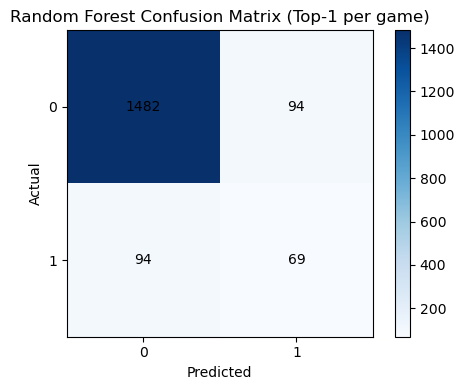

In [37]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Evaluate with the same top-1-per-game prediction logic used in metrics_df.
y_pred_top1_for_cm = pd.Series(0, index=scored_df.index, dtype=int)
y_pred_top1_for_cm.loc[winner_idx] = 1

print("Confusion Matrix (Top-1 per game):")
cm = confusion_matrix(y_test, y_pred_top1_for_cm)
print(cm)

try:
    import seaborn as sns

    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
    plt.title("Random Forest Confusion Matrix (Top-1 per game)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
except ModuleNotFoundError:
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title("Random Forest Confusion Matrix (Top-1 per game)")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks(range(cm.shape[1]))
    ax.set_yticks(range(cm.shape[0]))

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

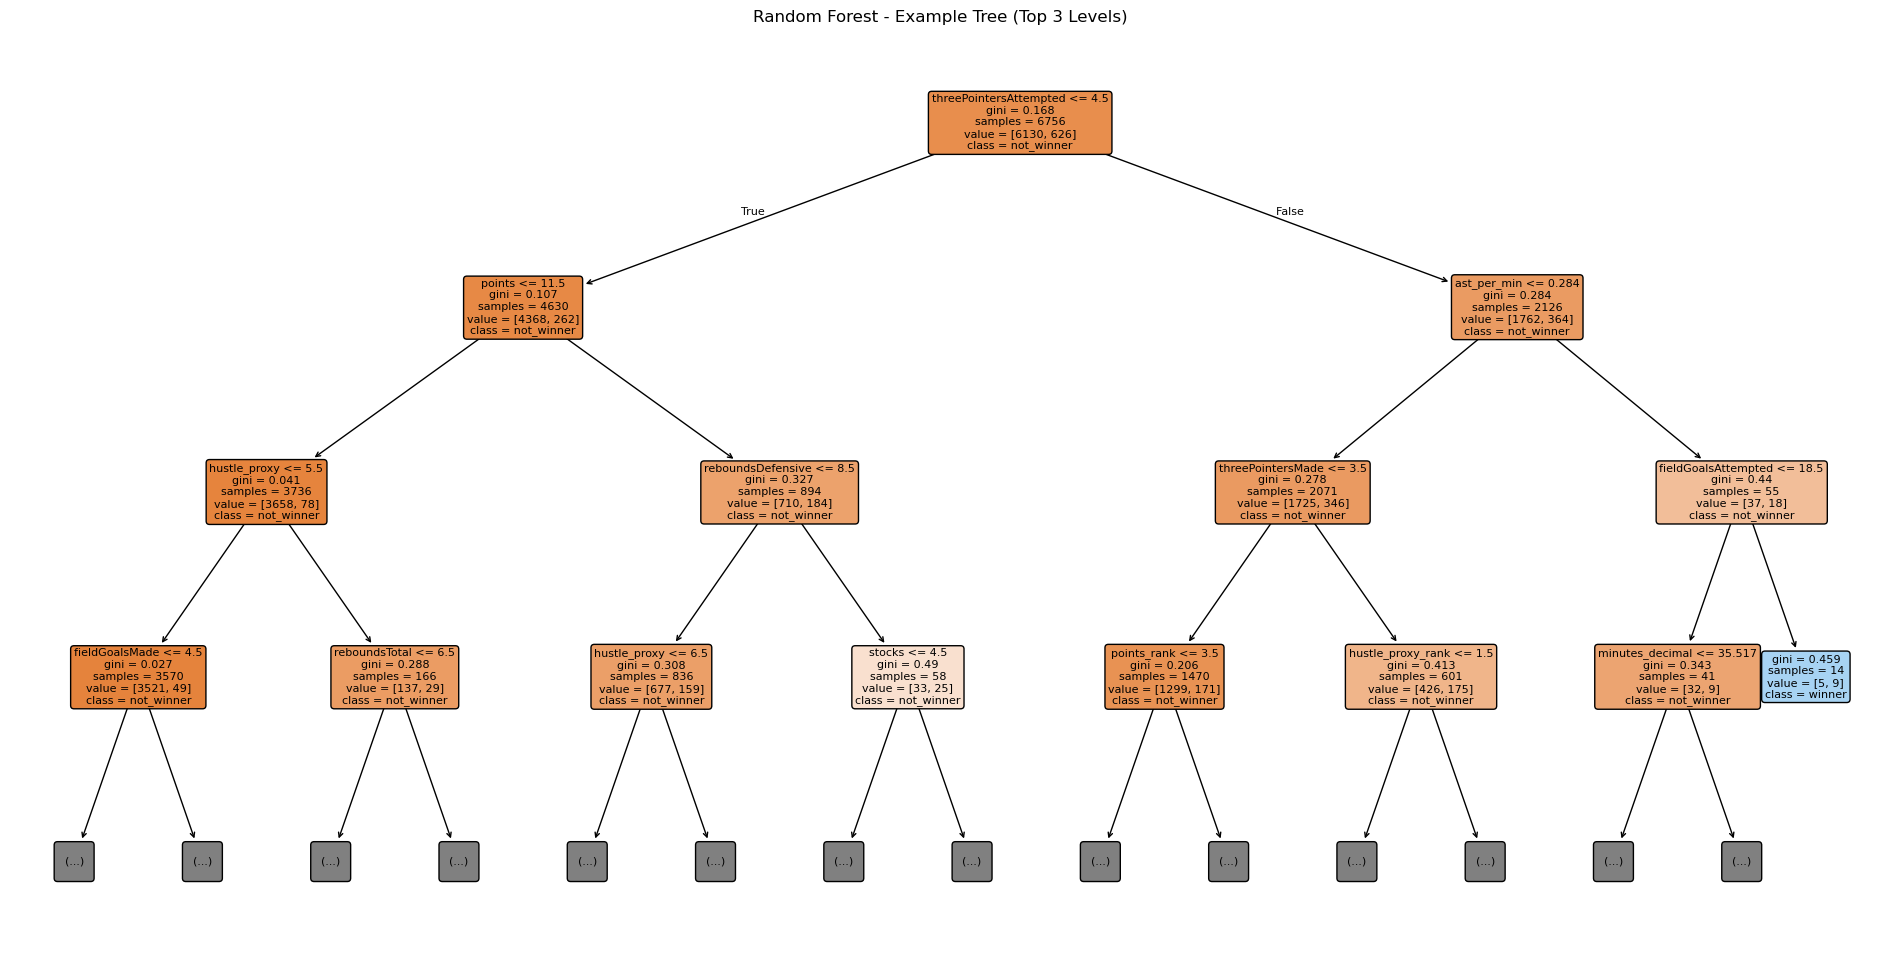

In [38]:
from sklearn import tree
import matplotlib.pyplot as plt

# Visualize one tree from the random forest (first estimator).
# Limiting depth keeps the plot readable.
one_tree = model.estimators_[0]

plt.figure(figsize=(24, 12))
tree.plot_tree(
    one_tree,
    feature_names=numeric_feature_cols,
    class_names=["not_winner", "winner"],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3,
)
plt.title("Random Forest - Example Tree (Top 3 Levels)")
plt.show()

## Predict Tommy Award Winners for Other NBA Teams

Apply the trained `model` (fit on Celtics games) to predict the player most likely to be the "Tommy Award" (team-player-of-the-game) winner for each of another team's games. Starting with the **New York Knicks**.

The pipeline pulls live data from `nba_api`, mirrors the same feature engineering used to train the model (per-minute stats, hustle proxy, per-game ranks, etc.), then takes the top-1 predicted probability per game as that game's predicted winner.

In [39]:
import sys
import subprocess

try:
    import nba_api
except ModuleNotFoundError:
    print("Installing nba_api into the current kernel's Python...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "nba_api"])
    import nba_api

print(f"Using Python: {sys.executable}")
print(f"nba_api version: {nba_api.__version__ if hasattr(nba_api, '__version__') else 'unknown'}")

Using Python: /Users/teddytaussig/anaconda3/envs/COM328/bin/python
nba_api version: 1.11.4


In [26]:
import sys
import time
from pathlib import Path

project_root = Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from csv_builders.build_tommy_award_player_game_table import (
    add_player_name_key,
    filter_team_players,
    get_date_column,
    get_game_id_column,
    get_team_id,
    get_team_schedule,
    get_traditional_player_box,
)
from csv_builders.enrich_player_game_with_hustle import (
    fetch_advanced_for_game,
    fetch_hustle_for_game,
)

TARGET_TEAMS = [
    "New York Knicks",
    "Los Angeles Lakers",
    "Oklahoma City Thunder",
    "Denver Nuggets",
    "Milwaukee Bucks",
]
TARGET_SEASONS = ["2024-25", "2025-26"]
SEASON_TYPES = ["Regular Season"]


def slugify_team(name: str) -> str:
    return name.lower().replace(" ", "_").replace(".", "")


team_configs = [
    {"name": name, "id": get_team_id(name), "slug": slugify_team(name)}
    for name in TARGET_TEAMS
]

ANALYSIS_TEAM_NAME = TARGET_TEAMS[0]
TARGET_TEAM_NAME = ANALYSIS_TEAM_NAME
TARGET_TEAM_ID = get_team_id(ANALYSIS_TEAM_NAME)
team_slug = slugify_team(ANALYSIS_TEAM_NAME)

predictions_dir = Path("predictions")
predictions_dir.mkdir(parents=True, exist_ok=True)

print(f"Teams to score: {[c['name'] for c in team_configs]}")
print(f"Seasons: {TARGET_SEASONS}, types: {SEASON_TYPES}")
print(f"SHAP analysis focus team: {ANALYSIS_TEAM_NAME}")

Target team: New York Knicks (team_id=1610612752)
Seasons: ['2024-25', '2025-26'], types: ['Regular Season']


In [40]:
def fetch_team_schedule(team_id: int, season: str, season_types: list[str]) -> pd.DataFrame:
    frames = []
    for season_type in season_types:
        sched = get_team_schedule(team_id=team_id, season=season, season_type=season_type)
        sched["SEASON_TYPE"] = season_type
        frames.append(sched)

    schedule_df = pd.concat(frames, ignore_index=True)
    sched_game_col = get_game_id_column(schedule_df)
    sched_date_col = get_date_column(schedule_df)
    schedule_df["GAME_ID"] = schedule_df[sched_game_col].astype(str).str.zfill(10)
    schedule_df["game_date"] = pd.to_datetime(schedule_df[sched_date_col]).dt.normalize()
    schedule_df = (
        schedule_df.drop_duplicates(subset=["GAME_ID"])
        .sort_values("game_date")
        .reset_index(drop=True)
    )
    return schedule_df


print("fetch_team_schedule defined. Execution is handled in the team-loop cell below.")

New York Knicks 2024-25: 82 games
New York Knicks 2025-26: 82 games

Sample of 2024-25 schedule:


,GAME_ID,game_date,MATCHUP,WL,SEASON_TYPE
0,0022400061,2024-10-22,NYK @ BOS,L,Regular Season
1,0022400081,2024-10-25,NYK vs. IND,W,Regular Season
2,0022400106,2024-10-28,NYK vs. CLE,L,Regular Season
3,0022400122,2024-10-30,NYK @ MIA,W,Regular Season
4,0022400134,2024-11-01,NYK @ DET,W,Regular Season



Sample of 2025-26 schedule:


,GAME_ID,game_date,MATCHUP,WL,SEASON_TYPE
0,0022500003,2025-10-22,NYK vs. CLE,W,Regular Season
1,0022500018,2025-10-24,NYK vs. BOS,W,Regular Season
2,0022500108,2025-10-26,NYK @ MIA,L,Regular Season
3,0022500125,2025-10-28,NYK @ MIL,L,Regular Season
4,0022500023,2025-10-31,NYK @ CHI,L,Regular Season


In [41]:
def fetch_player_game_raw(team_id, team_slug, season, schedule, cache_dir):
    """Fetch box score + hustle + advanced for each team game.

    Uses the enriched file as a cache - if it exists, skip the API pull entirely
    and return an empty DataFrame (cell 12 will load directly from the enriched CSV).
    """
    enriched_path = cache_dir / f"{team_slug}_{season}_player_game_enriched.csv"
    if enriched_path.exists():
        print(f"[{season}] Enriched cache exists at {enriched_path}; skipping API fetch.")
        return pd.DataFrame()

    box_frames = []
    hustle_frames = []
    advanced_frames = []
    total_games = len(schedule)

    for i, row in schedule.iterrows():
        gid = str(row["GAME_ID"])
        try:
            trad = get_traditional_player_box(gid)
            trad = filter_team_players(trad, team_id=team_id)
            trad = add_player_name_key(trad)
            trad["GAME_ID"] = gid
            trad["game_date"] = row["game_date"]
            box_frames.append(trad)
        except Exception as e:
            print(f"[{season}][{gid}] traditional box failed: {e}")
            continue

        hustle_frames.append(fetch_hustle_for_game(gid))
        advanced_frames.append(fetch_advanced_for_game(gid))

        if (i + 1) % 10 == 0 or (i + 1) == total_games:
            print(f"[{season}] Processed {i + 1}/{total_games} games")
        time.sleep(0.25)

    if not box_frames:
        print(f"[{season}] No games successfully fetched.")
        return pd.DataFrame()

    players_df = pd.concat(box_frames, ignore_index=True)
    players_df["personId"] = players_df["personId"].astype(str)

    hustle_df = pd.concat(hustle_frames, ignore_index=True) if hustle_frames else pd.DataFrame()
    if not hustle_df.empty:
        hustle_df = hustle_df.drop_duplicates(subset=["GAME_ID", "personId"])
        hustle_df["personId"] = hustle_df["personId"].astype(str)

    advanced_df = pd.concat(advanced_frames, ignore_index=True) if advanced_frames else pd.DataFrame()
    if not advanced_df.empty:
        advanced_df = advanced_df.drop_duplicates(subset=["GAME_ID", "personId"])
        advanced_df["personId"] = advanced_df["personId"].astype(str)

    combined = players_df.copy()
    if not hustle_df.empty:
        combined = combined.merge(hustle_df, on=["GAME_ID", "personId"], how="left")
    else:
        combined["deflections"] = np.nan
        combined["charges_drawn"] = np.nan

    if not advanced_df.empty:
        combined = combined.merge(advanced_df, on=["GAME_ID", "personId"], how="left")
    else:
        combined["usage_rate"] = np.nan

    return combined


print("fetch_player_game_raw defined. Execution is handled in the team-loop cell below.")


[2024-25] Enriched cache exists at predictions/new_york_knicks_2024-25_player_game_enriched.csv; skipping API fetch.
[2025-26] Enriched cache exists at predictions/new_york_knicks_2025-26_player_game_enriched.csv; skipping API fetch.


In [42]:
def _minutes_to_decimal(val):
    if pd.isna(val):
        return np.nan
    if isinstance(val, (int, float)):
        return float(val)
    s = str(val).strip()
    if not s:
        return np.nan
    if ":" in s:
        parts = s.split(":")
        try:
            mins_part = float(parts[0])
            secs_part = float(parts[1]) if len(parts) > 1 else 0.0
            return mins_part + secs_part / 60.0
        except ValueError:
            return np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan


CELTICS_COLUMN_ORDER = [
    "gameId", "teamId", "teamCity", "teamName", "teamTricode", "teamSlug",
    "personId", "firstName", "familyName", "nameI", "playerSlug", "position",
    "comment", "jerseyNum", "minutes", "minutes_decimal",
    "fieldGoalsMade", "fieldGoalsAttempted", "fieldGoalsPercentage",
    "threePointersMade", "threePointersAttempted", "threePointersPercentage",
    "freeThrowsMade", "freeThrowsAttempted", "freeThrowsPercentage",
    "reboundsOffensive", "reboundsDefensive", "reboundsTotal",
    "assists", "steals", "blocks", "turnovers", "foulsPersonal",
    "points", "plusMinusPoints",
    "GAME_ID", "player_name", "player_name_key", "y", "winner_names", "game_date",
    "stocks", "points_per_min", "oreb_per_min", "reb_per_min", "ast_per_min",
    "hustle_proxy",
    "points_rank", "reboundsOffensive_rank", "reboundsTotal_rank",
    "assists_rank", "steals_rank", "blocks_rank",
    "plusMinusPoints_rank", "minutes_decimal_rank",
    "deflections", "deflections_missing",
    "charges_drawn", "charges_drawn_missing",
    "usage_rate",
]

EXTRA_FEATURE_COLS = [
    "net_rating", "impact_efficiency", "role_outperformance",
    "stocks_per_min", "stocks_rank", "hustle_proxy_rank",
]


def build_and_score_team_season(raw_df, season, team_name, team_slug, cache_dir, model, numeric_feature_cols, X_train):
    enriched_path = cache_dir / f"{team_slug}_{season}_player_game_enriched.csv"

    if raw_df.empty and enriched_path.exists():
        print(f"[{season}] Loading scored rows from cached enriched file {enriched_path}")
        return pd.read_csv(enriched_path, dtype={"GAME_ID": str, "personId": str})

    if raw_df.empty:
        print(f"[{season}] No raw data and no enriched cache - skipping.")
        return pd.DataFrame()

    team_df = raw_df.copy()

    if "minutes_decimal" not in team_df.columns or team_df["minutes_decimal"].isna().all():
        mins_source = team_df["minutes"] if "minutes" in team_df.columns else team_df.get("MIN")
        team_df["minutes_decimal"] = mins_source.map(_minutes_to_decimal)
    else:
        team_df["minutes_decimal"] = pd.to_numeric(team_df["minutes_decimal"], errors="coerce")
        missing_mask = team_df["minutes_decimal"].isna()
        if missing_mask.any() and "minutes" in team_df.columns:
            team_df.loc[missing_mask, "minutes_decimal"] = team_df.loc[missing_mask, "minutes"].map(_minutes_to_decimal)

    team_df = team_df[team_df["minutes_decimal"] > 0].copy()

    numeric_source_cols = [
        "points", "reboundsOffensive", "reboundsDefensive", "reboundsTotal",
        "assists", "steals", "blocks", "turnovers", "foulsPersonal",
        "plusMinusPoints", "fieldGoalsMade", "fieldGoalsAttempted",
        "threePointersMade", "threePointersAttempted",
        "freeThrowsMade", "freeThrowsAttempted",
        "deflections", "charges_drawn", "usage_rate",
    ]
    for col in numeric_source_cols:
        if col not in team_df.columns:
            team_df[col] = np.nan
        team_df[col] = pd.to_numeric(team_df[col], errors="coerce")

    mins = team_df["minutes_decimal"].clip(lower=1e-6)

    team_df["stocks"] = team_df["steals"].fillna(0) + team_df["blocks"].fillna(0)
    team_df["points_per_min"] = team_df["points"] / mins
    team_df["oreb_per_min"] = team_df["reboundsOffensive"] / mins
    team_df["reb_per_min"] = team_df["reboundsTotal"] / mins
    team_df["ast_per_min"] = team_df["assists"] / mins
    team_df["stocks_per_min"] = team_df["stocks"] / mins
    team_df["hustle_proxy"] = (
        team_df["reboundsOffensive"].fillna(0)
        + team_df["steals"].fillna(0)
        + team_df["blocks"].fillna(0)
    ) / mins

    team_df["net_rating"] = team_df["plusMinusPoints"]
    eps = 1e-6
    team_df["impact_efficiency"] = team_df["net_rating"] / (team_df["usage_rate"] + eps)
    team_df["role_outperformance"] = team_df["net_rating"] * (1 - team_df["usage_rate"])

    team_df["deflections_missing"] = team_df["deflections"].isna().astype(int)
    team_df["charges_drawn_missing"] = team_df["charges_drawn"].isna().astype(int)

    rank_sources = {
        "points_rank": "points",
        "reboundsOffensive_rank": "reboundsOffensive",
        "reboundsTotal_rank": "reboundsTotal",
        "assists_rank": "assists",
        "steals_rank": "steals",
        "blocks_rank": "blocks",
        "plusMinusPoints_rank": "plusMinusPoints",
        "minutes_decimal_rank": "minutes_decimal",
        "stocks_rank": "stocks",
        "hustle_proxy_rank": "hustle_proxy",
    }
    for rank_col, source_col in rank_sources.items():
        team_df[rank_col] = team_df.groupby("GAME_ID")[source_col].rank(method="min", ascending=False)

    if "y" not in team_df.columns:
        team_df["y"] = pd.NA
    if "winner_names" not in team_df.columns:
        team_df["winner_names"] = pd.NA

    missing_features = [c for c in numeric_feature_cols if c not in team_df.columns]
    if missing_features:
        raise ValueError(f"[{season}] Missing engineered features: {missing_features}")

    train_medians = X_train.median(numeric_only=True)
    X_team = team_df[numeric_feature_cols].copy().fillna(train_medians)
    team_df["pred_prob"] = model.predict_proba(X_team)[:, 1]

    for col in CELTICS_COLUMN_ORDER:
        if col not in team_df.columns:
            team_df[col] = pd.NA

    enriched_df = team_df[CELTICS_COLUMN_ORDER + EXTRA_FEATURE_COLS + ["pred_prob"]].copy()
    enriched_path = cache_dir / f"{team_slug}_{season}_player_game_enriched.csv"
    enriched_df.to_csv(enriched_path, index=False)
    print(f"[{season}] Saved enriched player-game data to {enriched_path}")
    print(f"[{season}] Scored {len(team_df)} rows across {team_df['GAME_ID'].nunique()} games")
    return team_df


print("build_and_score_team_season defined. Execution is handled in the team-loop cell below.")


[2024-25] Loading scored rows from cached enriched file predictions/new_york_knicks_2024-25_player_game_enriched.csv
[2025-26] Loading scored rows from cached enriched file predictions/new_york_knicks_2025-26_player_game_enriched.csv

[2024-25] Sample scored rows:


,GAME_ID,game_date,player_name,minutes_decimal,points,reboundsTotal,assists,stocks,plusMinusPoints,pred_prob
0,0022400061,2024-10-22,OG Anunoby,34.166667,4,5,3,1,-21.0,0.001706
1,0022400061,2024-10-22,Josh Hart,24.500000,12,4,3,0,-23.0,0.094767
2,0022400061,2024-10-22,Karl-Anthony Towns,23.616667,12,7,3,0,-18.0,0.071840
3,0022400061,2024-10-22,Mikal Bridges,34.616667,16,0,2,0,-33.0,0.267954
4,0022400061,2024-10-22,Jalen Brunson,24.500000,22,1,2,0,-23.0,0.338491



[2025-26] Sample scored rows:


,GAME_ID,game_date,player_name,minutes_decimal,points,reboundsTotal,assists,stocks,plusMinusPoints,pred_prob
0,0022500003,2025-10-22,OG Anunoby,37.500000,24,14,2,4,10.0,0.266339
1,0022500003,2025-10-22,Karl-Anthony Towns,31.000000,19,11,2,0,2.0,0.249420
2,0022500003,2025-10-22,Ariel Hukporti,17.750000,2,5,2,1,-4.0,0.001638
3,0022500003,2025-10-22,Mikal Bridges,33.200000,16,5,6,5,1.0,0.286703
4,0022500003,2025-10-22,Jalen Brunson,34.383333,23,4,5,0,6.0,0.128324


In [43]:
def summarize_season(scored_df, season, team_name):
    """In-memory per-season summary - no CSV writes.

    Per-season detail (including pred_prob) is already saved in the enriched CSV.
    We only show winners and counts for visibility, then roll everything up
    into a single combined CSV across seasons.
    """
    if scored_df.empty:
        print(f"[{season}] No scored rows - skipping.")
        return None

    winner_idx = scored_df.groupby("GAME_ID")["pred_prob"].idxmax()
    predicted_winners = (
        scored_df.loc[winner_idx]
        .sort_values("game_date")
        .reset_index(drop=True)
    )

    winner_cols = [
        "GAME_ID", "game_date", "player_name", "minutes_decimal",
        "points", "reboundsTotal", "assists", "stocks",
        "plusMinusPoints", "pred_prob",
    ]
    winner_cols = [c for c in winner_cols if c in predicted_winners.columns]

    print(f"\n[{season}] Predicted Tommy Award winner per game - {team_name}")
    display(predicted_winners[winner_cols].head(20))

    winner_counts = (
        predicted_winners.groupby("player_name")
        .size()
        .reset_index(name="predicted_wins")
        .sort_values("predicted_wins", ascending=False)
        .reset_index(drop=True)
    )
    print(f"[{season}] Season-long Tommy Award tally:")
    display(winner_counts)

    return {
        "predicted_winners": predicted_winners,
        "winner_counts": winner_counts,
    }


all_team_scored = {}
all_team_combined_counts = {}

for cfg in team_configs:
    team_name = cfg["name"]
    team_id = cfg["id"]
    team_slug_i = cfg["slug"]
    print(f"\n{'=' * 70}\nProcessing {team_name} (team_id={team_id})\n{'=' * 70}")

    schedules_by_season = {}
    for season in TARGET_SEASONS:
        sched_df = fetch_team_schedule(team_id, season, SEASON_TYPES)
        schedules_by_season[season] = sched_df
        print(f"  [{season}] schedule: {len(sched_df)} games")

    raw_by_season = {}
    for season, sched in schedules_by_season.items():
        raw_by_season[season] = fetch_player_game_raw(
            team_id, team_slug_i, season, sched, predictions_dir
        )

    scored_by_season = {}
    for season, raw_df in raw_by_season.items():
        scored_by_season[season] = build_and_score_team_season(
            raw_df=raw_df,
            season=season,
            team_name=team_name,
            team_slug=team_slug_i,
            cache_dir=predictions_dir,
            model=model,
            numeric_feature_cols=numeric_feature_cols,
            X_train=X_train,
        )
    all_team_scored[team_name] = scored_by_season

    season_summaries = {}
    for season, scored in scored_by_season.items():
        season_summaries[season] = summarize_season(
            scored_df=scored, season=season, team_name=team_name
        )

    valid_counts = [
        s["winner_counts"].assign(season=season)
        for season, s in season_summaries.items()
        if s is not None
    ]
    if valid_counts:
        combined_counts = (
            pd.concat(valid_counts, ignore_index=True)
            .pivot_table(
                index="player_name",
                columns="season",
                values="predicted_wins",
                fill_value=0,
            )
            .assign(total=lambda d: d.sum(axis=1))
            .sort_values("total", ascending=False)
        )
        combined_out = predictions_dir / f"{team_slug_i}_predicted_tommy_counts_combined.csv"
        combined_counts.to_csv(combined_out)
        all_team_combined_counts[team_name] = combined_counts
        print(f"\n[{team_name}] Combined cross-season tally saved to {combined_out}")
        display(combined_counts.head(10))

league_rows = []
for team_name, counts_df in all_team_combined_counts.items():
    top = counts_df.head(1).reset_index()
    if not top.empty:
        top.insert(0, "team", team_name)
        league_rows.append(top)

if league_rows:
    league_leaders = pd.concat(league_rows, ignore_index=True).sort_values("total", ascending=False)
    league_out = predictions_dir / "league_predicted_tommy_leaders.csv"
    league_leaders.to_csv(league_out, index=False)
    print(f"\n{'=' * 70}\nLeague-wide predicted Tommy leaders (top player per team):")
    display(league_leaders)
    print(f"Saved to {league_out}")



[2024-25] Predicted Tommy Award winner per game - New York Knicks


,GAME_ID,game_date,player_name,minutes_decimal,points,reboundsTotal,assists,stocks,plusMinusPoints,pred_prob
0,0022400061,2024-10-22,Miles McBride,25.850000,22,0,2,0,-18.0,0.375276
1,0022400081,2024-10-25,Karl-Anthony Towns,32.300000,21,15,0,3,17.0,0.439407
2,0022400106,2024-10-28,Mikal Bridges,40.166667,19,6,3,3,-14.0,0.225182
3,0022400122,2024-10-30,Josh Hart,42.233333,10,14,6,1,9.0,0.317447
4,0022400134,2024-11-01,Karl-Anthony Towns,27.483333,21,11,7,3,28.0,0.358111
5,0022400161,2024-11-04,Karl-Anthony Towns,32.416667,17,19,0,1,-26.0,0.492846
6,0022400171,2024-11-06,Karl-Anthony Towns,38.016667,34,16,1,4,-12.0,0.434495
7,0022400189,2024-11-08,Jalen Brunson,31.766667,15,2,9,1,28.0,0.183194
8,0022400203,2024-11-10,Jalen Brunson,40.616667,33,6,10,0,-8.0,0.443141
9,0022400004,2024-11-12,Josh Hart,37.400000,14,12,10,2,16.0,0.455972


[2024-25] Season-long Tommy Award tally:


,player_name,predicted_wins
0,Karl-Anthony Towns,31
1,Jalen Brunson,19
2,Josh Hart,10
3,OG Anunoby,6
4,Miles McBride,5
5,Mikal Bridges,5
6,Cameron Payne,2
7,Landry Shamet,2
8,Mitchell Robinson,2



[2025-26] Predicted Tommy Award winner per game - New York Knicks


...

[2025-26] Season-long Tommy Award tally:


,player_name,predicted_wins
0,Karl-Anthony Towns,26
1,Jalen Brunson,20
2,Miles McBride,7
3,Mitchell Robinson,6
4,Mikal Bridges,6
5,OG Anunoby,5
6,Josh Hart,3
7,Jordan Clarkson,2
8,Jose Alvarado,2
9,Landry Shamet,2



Combined predicted Tommy Award tally for New York Knicks across ['2024-25', '2025-26']:


season,2024-25,2025-26,total
player_name,,,
Karl-Anthony Towns,31.0,26.0,57.0
Jalen Brunson,19.0,20.0,39.0
Josh Hart,10.0,3.0,13.0
Miles McBride,5.0,7.0,12.0
OG Anunoby,6.0,5.0,11.0
Mikal Bridges,5.0,6.0,11.0
Mitchell Robinson,2.0,6.0,8.0
Landry Shamet,2.0,2.0,4.0
Cameron Payne,2.0,0.0,2.0


Saved combined cross-season tally to predictions/new_york_knicks_predicted_tommy_counts_combined.csv


## Why did a particular player win the most predicted Tommy Awards?

Use SHAP values on the trained Random Forest to see which features pushed a player's predicted probability up on the nights they were predicted winners. For a random forest, SHAP's `TreeExplainer` gives an exact per-row, per-feature contribution to the predicted probability, which is the principled way to answer "what was the most informative statistic?".

Default is Karl-Anthony Towns; change `FOCUS_PLAYER` to analyze anyone else.

In [44]:
from __future__ import annotations

import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import shap
except ModuleNotFoundError:
    print("Installing shap into current kernel...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "shap"])
    import shap

FOCUS_PLAYER = "Karl-Anthony Towns"
TOP_N_FEATURES = 15

enriched_frames = []
for season in TARGET_SEASONS:
    path = predictions_dir / f"{team_slug}_{season}_player_game_enriched.csv"
    if path.exists():
        season_df = pd.read_csv(path, dtype={"GAME_ID": str, "personId": str})
        season_df["season"] = season
        enriched_frames.append(season_df)

if not enriched_frames:
    raise FileNotFoundError("No enriched CSVs found - run cells 8-13 first.")

all_enriched = pd.concat(enriched_frames, ignore_index=True)
per_game_rank = all_enriched.groupby(["season", "GAME_ID"])["pred_prob"].rank(method="min", ascending=False)
winner_rows = all_enriched[per_game_rank == 1].copy()

print(f"{TARGET_TEAM_NAME} predicted Tommy winners: {len(winner_rows)} games across {len(TARGET_SEASONS)} seasons")
display(
    winner_rows.groupby("player_name").size()
    .reset_index(name="predicted_wins")
    .sort_values("predicted_wins", ascending=False)
    .reset_index(drop=True)
)


Karl-Anthony Towns: 57 predicted Tommy wins across 2 season(s)


,season,predicted_wins
0,2024-25,31
1,2025-26,26


In [45]:
from __future__ import annotations

import numpy as np
import pandas as pd
import shap
from IPython.display import display

explainer = shap.TreeExplainer(model)
train_medians = X_train.median(numeric_only=True)

X_winners = winner_rows[numeric_feature_cols].copy().fillna(train_medians)
shap_raw = explainer.shap_values(X_winners, check_additivity=False)

if isinstance(shap_raw, list):
    shap_winner = shap_raw[1]
elif hasattr(shap_raw, "ndim") and shap_raw.ndim == 3:
    shap_winner = shap_raw[..., 1]
else:
    shap_winner = shap_raw

shap_winner_df = pd.DataFrame(shap_winner, columns=numeric_feature_cols, index=X_winners.index)

team_feature_importance = pd.DataFrame({
    "feature": numeric_feature_cols,
    "mean_shap": shap_winner_df.mean(axis=0).values,
    "mean_abs_shap": shap_winner_df.abs().mean(axis=0).values,
    "winner_mean_value": X_winners.mean(axis=0).values,
    "train_median": train_medians.reindex(numeric_feature_cols).values,
})

print(f"=== {TARGET_TEAM_NAME}: MOST IMPORTANT features driving Tommy Award picks ===")
print(f"(Computed across all {len(winner_rows)} predicted-winner rows over {len(TARGET_SEASONS)} seasons)")

print("\nSorted by mean |SHAP| - features the model relies on MOST when picking Knicks winners:")
display(
    team_feature_importance.sort_values("mean_abs_shap", ascending=False)
    .head(TOP_N_FEATURES)
    .reset_index(drop=True)
)

print("\nSorted by mean SHAP (signed) - features that most consistently push probability toward Tommy winner:")
display(
    team_feature_importance.sort_values("mean_shap", ascending=False)
    .head(TOP_N_FEATURES)
    .reset_index(drop=True)
)

=== New York Knicks: MOST IMPORTANT features driving Tommy Award picks ===
(Computed across all 164 predicted-winner rows over 2 seasons)

Sorted by mean |SHAP| - features the model relies on MOST when picking Knicks winners:


,feature,mean_shap,mean_abs_shap,winner_mean_value,train_median
0,points,0.052103,0.053216,24.829268,8.000000
1,fieldGoalsMade,0.048265,0.049170,8.926829,3.000000
2,points_per_min,0.040283,0.044846,0.758956,0.391400
3,points_rank,0.032451,0.035081,1.963415,6.000000
4,reb_per_min,0.016570,0.017979,0.262163,0.167500
5,reboundsTotal,0.015952,0.016828,8.426829,4.000000
6,plusMinusPoints_rank,0.006234,0.014537,4.256098,6.000000
7,threePointersMade,0.009030,0.013038,2.621951,1.000000
8,usage_rate,0.002268,0.012319,0.002534,0.001820
9,fieldGoalsAttempted,0.004424,0.009971,15.871951,7.000000



Sorted by mean SHAP (signed) - features that most consistently push probability toward Tommy winner:


,feature,mean_shap,mean_abs_shap,winner_mean_value,train_median
0,points,0.052103,0.053216,24.829268,8.000000
1,fieldGoalsMade,0.048265,0.049170,8.926829,3.000000
2,points_per_min,0.040283,0.044846,0.758956,0.391400
3,points_rank,0.032451,0.035081,1.963415,6.000000
4,reb_per_min,0.016570,0.017979,0.262163,0.167500
5,reboundsTotal,0.015952,0.016828,8.426829,4.000000
6,threePointersMade,0.009030,0.013038,2.621951,1.000000
7,reboundsOffensive,0.007444,0.008379,2.317073,1.000000
8,assists,0.007304,0.009736,4.341463,2.000000
9,minutes_decimal,0.007177,0.007738,33.154268,23.516667


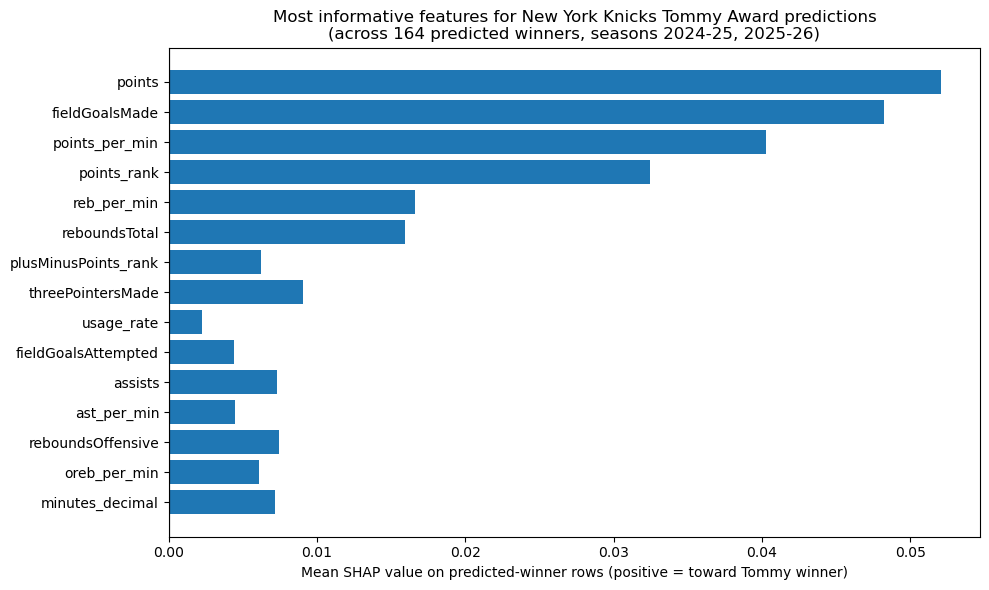

=== Focused breakdown for Karl-Anthony Towns ===

Top features pushing Karl-Anthony Towns's predicted probability UP across his 57 wins:


,feature,mean_shap_for_focus,mean_abs_shap_for_focus,focus_mean_value,train_median
0,points,0.049644,0.049644,25.210526,8.000000
1,fieldGoalsMade,0.046445,0.046445,8.982456,3.000000
2,points_per_min,0.040449,0.042634,0.765254,0.391400
3,reb_per_min,0.034175,0.034583,0.435682,0.167500
4,reboundsTotal,0.032082,0.032167,14.245614,4.000000
5,points_rank,0.029604,0.030945,1.842105,6.000000
6,reboundsOffensive,0.014580,0.014909,3.877193,1.000000
7,oreb_per_min,0.012580,0.012858,0.118768,0.026900
8,reboundsDefensive,0.010548,0.010811,10.368421,3.000000
9,reboundsTotal_rank,0.005740,0.006235,1.105263,5.000000


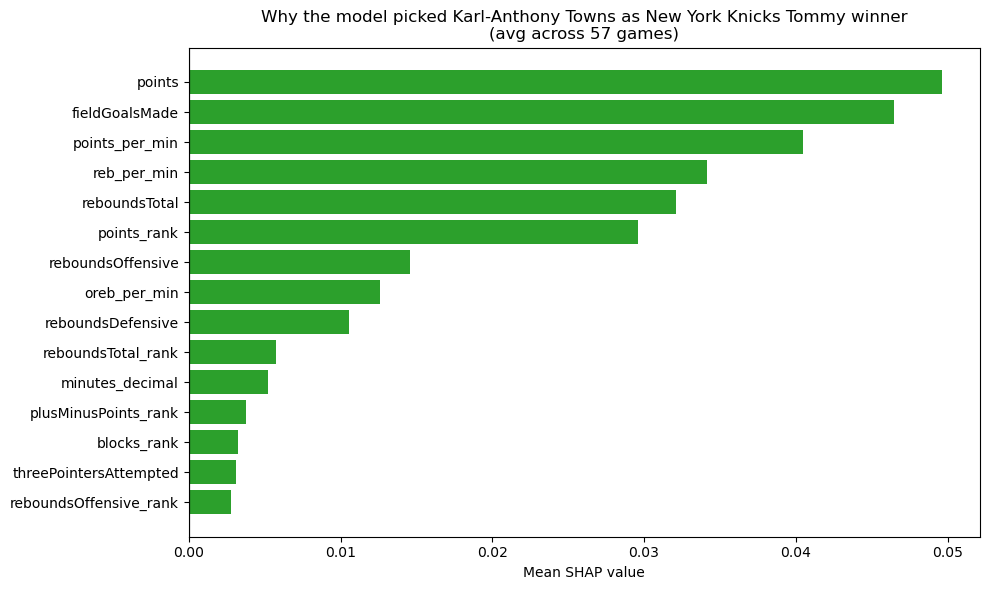

In [46]:
from __future__ import annotations

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

top_abs = (
    team_feature_importance.sort_values("mean_abs_shap", ascending=False)
    .head(TOP_N_FEATURES)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, max(4.5, 0.4 * len(top_abs))))
colors = ["#1f77b4" if v >= 0 else "#d62728" for v in top_abs["mean_shap"]]
ax.barh(top_abs["feature"][::-1], top_abs["mean_shap"][::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Mean SHAP value on predicted-winner rows (positive = toward Tommy winner)")
ax.set_title(f"Most informative features for {TARGET_TEAM_NAME} Tommy Award predictions\n(across {len(winner_rows)} predicted winners, seasons {', '.join(TARGET_SEASONS)})")
plt.tight_layout()
plt.show()

print(f"=== Focused breakdown for {FOCUS_PLAYER} ===")
focus_mask = winner_rows["player_name"].str.strip().str.lower() == FOCUS_PLAYER.strip().lower()
if not focus_mask.any():
    print(f"{FOCUS_PLAYER} has no predicted wins - skipping per-player breakdown.")
else:
    focus_idx = winner_rows.index[focus_mask]
    focus_shap = shap_winner_df.loc[focus_idx]
    focus_X = X_winners.loc[focus_idx]

    focus_summary = pd.DataFrame({
        "feature": numeric_feature_cols,
        "mean_shap_for_focus": focus_shap.mean(axis=0).values,
        "mean_abs_shap_for_focus": focus_shap.abs().mean(axis=0).values,
        "focus_mean_value": focus_X.mean(axis=0).values,
        "train_median": train_medians.reindex(numeric_feature_cols).values,
    }).sort_values("mean_shap_for_focus", ascending=False).reset_index(drop=True)

    print(f"\nTop features pushing {FOCUS_PLAYER}'s predicted probability UP across his {len(focus_idx)} wins:")
    display(focus_summary.head(TOP_N_FEATURES))

    fig, ax = plt.subplots(figsize=(10, max(4.5, 0.4 * TOP_N_FEATURES)))
    focus_top = focus_summary.head(TOP_N_FEATURES)
    colors_f = ["#2ca02c" if v >= 0 else "#d62728" for v in focus_top["mean_shap_for_focus"]]
    ax.barh(focus_top["feature"][::-1], focus_top["mean_shap_for_focus"][::-1], color=colors_f[::-1])
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Mean SHAP value")
    ax.set_title(f"Why the model picked {FOCUS_PLAYER} as {TARGET_TEAM_NAME} Tommy winner\n(avg across {len(focus_idx)} games)")
    plt.tight_layout()
    plt.show()